# Validation 04: Backend Cross-Validation Atlas

This notebook reads the outputs from `examples/validation_backend_cross_validation.py` and turns them into a discrepancy report.

The goal is **not** to declare one model correct. The goal is to document where effective implementations agree or diverge:

- CIGALE + BC03 stellar;
- CIGALE + BC03 stellar + CIGALE nebular;
- CIGALE + experimental FSPS stellar;
- CIGALE + experimental FSPS stellar + CIGALE nebular;
- direct python-FSPS stellar;
- direct python-FSPS stellar + FSPS nebular;
- JAX-CIGALE DSPS + Cue nebular, when available.

The labels `expected`, `suspicious`, and `unresolved` are first-pass audit flags, not final scientific judgement.


## 1. Load Outputs

Run the staged validation first if these files do not exist:

```bash
SPS_HOME=/Users/gregoire/Work/FSPS PYTHONPATH=/Users/gregoire/Documents/Sedfitting/CompoSED /Users/gregoire/opt/anaconda3/envs/sbi_candide/bin/python     examples/validation_backend_cross_validation.py --stage references --n-draws 80

PYTHONPATH=/Users/gregoire/Documents/Sedfitting/CompoSED DSPS_SSP_FILE="/Users/gregoire/Documents/New project 2/dsps_data/ssp_data_fsps_v3.2_lgmet_age.h5" CUE_DATA_DIR=/private/tmp/cue/src/cue/data /Users/gregoire/miniforge3/envs/dsps_nuts/bin/python     examples/validation_backend_cross_validation.py --stage cue --n-draws 80

python examples/validation_backend_cross_validation.py --stage plots --n-draws 80
```


In [1]:
from pathlib import Path
import csv
import json

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"notebooks", "validation"}:
    while PROJECT_ROOT.name != "CompoSED" and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "outputs/validation_backend_cross_validation"
print("Output directory:", OUTPUT_DIR)
print("Exists:", OUTPUT_DIR.exists())

metrics_path = OUTPUT_DIR / "cross_validation_metrics.json"
draws_path = OUTPUT_DIR / "parameter_draws.json"
reference_path = OUTPUT_DIR / "reference_spectra.npz"
cue_path = OUTPUT_DIR / "cue_spectra.npz"

if not metrics_path.exists():
    print("Metrics do not exist yet. The staged validation run is probably still running.")
else:
    metrics = json.loads(metrics_path.read_text())
    draws = json.loads(draws_path.read_text())
    reference = np.load(reference_path, allow_pickle=True) if reference_path.exists() else None
    cue = np.load(cue_path, allow_pickle=True) if cue_path.exists() else None
    print("Loaded metrics:", len(metrics))
    print("Loaded draws:", len(draws))
    print("Reference spectra:", reference_path.exists())
    print("Cue spectra:", cue_path.exists())


Output directory: /Users/gregoire/Documents/Sedfitting/CompoSED/outputs/validation_backend_cross_validation
Exists: True
Loaded metrics: 400
Loaded draws: 80
Reference spectra: True
Cue spectra: False


## 2. Status Counts

This summarizes the automated audit labels. The point is to guide inspection, not to replace it.


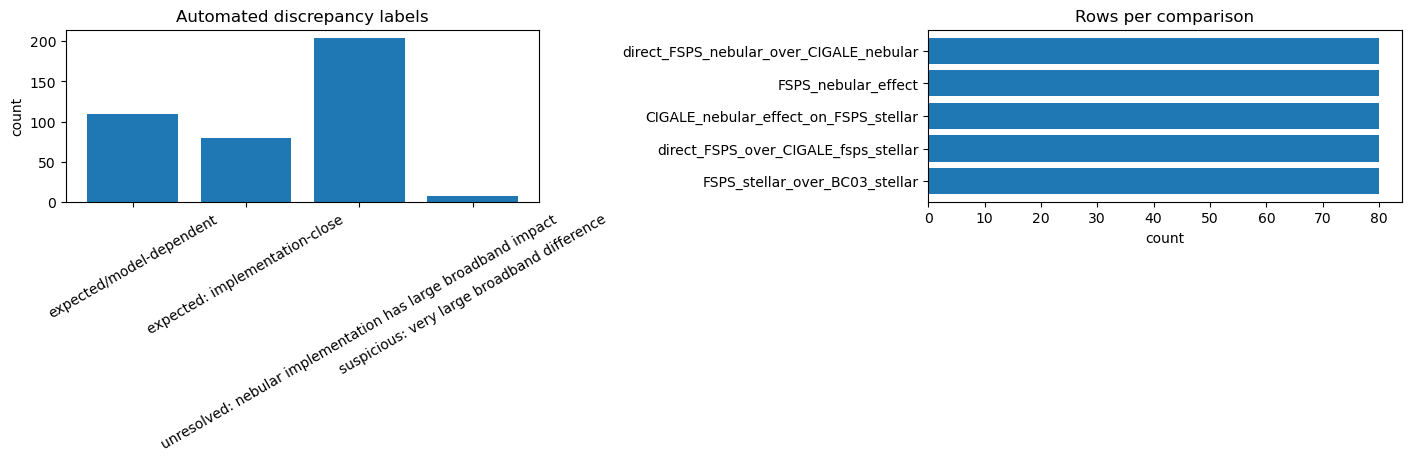

expected/model-dependent                                               109
expected: implementation-close                                         80
suspicious: very large broadband difference                            7
unresolved: nebular implementation has large broadband impact          204


In [2]:
if metrics_path.exists():
    status_counts = {}
    comparison_counts = {}
    for row in metrics:
        status_counts[row["status"]] = status_counts.get(row["status"], 0) + 1
        comparison_counts[row["comparison"]] = comparison_counts.get(row["comparison"], 0) + 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
    axes[0].bar(list(status_counts), list(status_counts.values()))
    axes[0].set_title("Automated discrepancy labels")
    axes[0].set_ylabel("count")
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].barh(list(comparison_counts), list(comparison_counts.values()))
    axes[1].set_title("Rows per comparison")
    axes[1].set_xlabel("count")
    plt.show()

    for key, value in sorted(status_counts.items()):
        print(f"{key:70s} {value}")


## 3. Worst Broadband Differences

These are the cases to inspect first because they alter actual synthetic photometry, not just narrow spectral pixels.


In [3]:
if metrics_path.exists():
    def finite_float(value):
        if value is None:
            return np.nan
        value = float(value)
        return value if np.isfinite(value) else np.nan

    ranked = sorted(metrics, key=lambda row: finite_float(row.get("max_abs_delta_mag")), reverse=True)
    for row in ranked[:20]:
        print(
            f"{row['label']:10s} {row['comparison']:45s} "
            f"max|dmag|={finite_float(row.get('max_abs_delta_mag')):7.3f} "
            f"status={row['status']}"
        )


draw_0060  CIGALE_nebular_effect_on_FSPS_stellar         max|dmag|= 14.360 status=unresolved: nebular implementation has large broadband impact
draw_0005  CIGALE_nebular_effect_on_FSPS_stellar         max|dmag|= 13.409 status=unresolved: nebular implementation has large broadband impact
draw_0048  CIGALE_nebular_effect_on_FSPS_stellar         max|dmag|= 12.799 status=unresolved: nebular implementation has large broadband impact
draw_0064  CIGALE_nebular_effect_on_FSPS_stellar         max|dmag|= 12.668 status=unresolved: nebular implementation has large broadband impact
draw_0025  CIGALE_nebular_effect_on_FSPS_stellar         max|dmag|= 12.492 status=unresolved: nebular implementation has large broadband impact
draw_0017  CIGALE_nebular_effect_on_FSPS_stellar         max|dmag|= 12.404 status=unresolved: nebular implementation has large broadband impact
draw_0068  CIGALE_nebular_effect_on_FSPS_stellar         max|dmag|= 12.286 status=unresolved: nebular implementation has large broadband

## 4. Saved Atlas Figures

These figures are produced by the validation script. The single-SED atlas is intentionally detailed; the heatmaps summarize the sweep.


/Users/gregoire/Documents/Sedfitting/CompoSED/outputs/validation_backend_cross_validation/single_sed_cross_validation_atlas.png


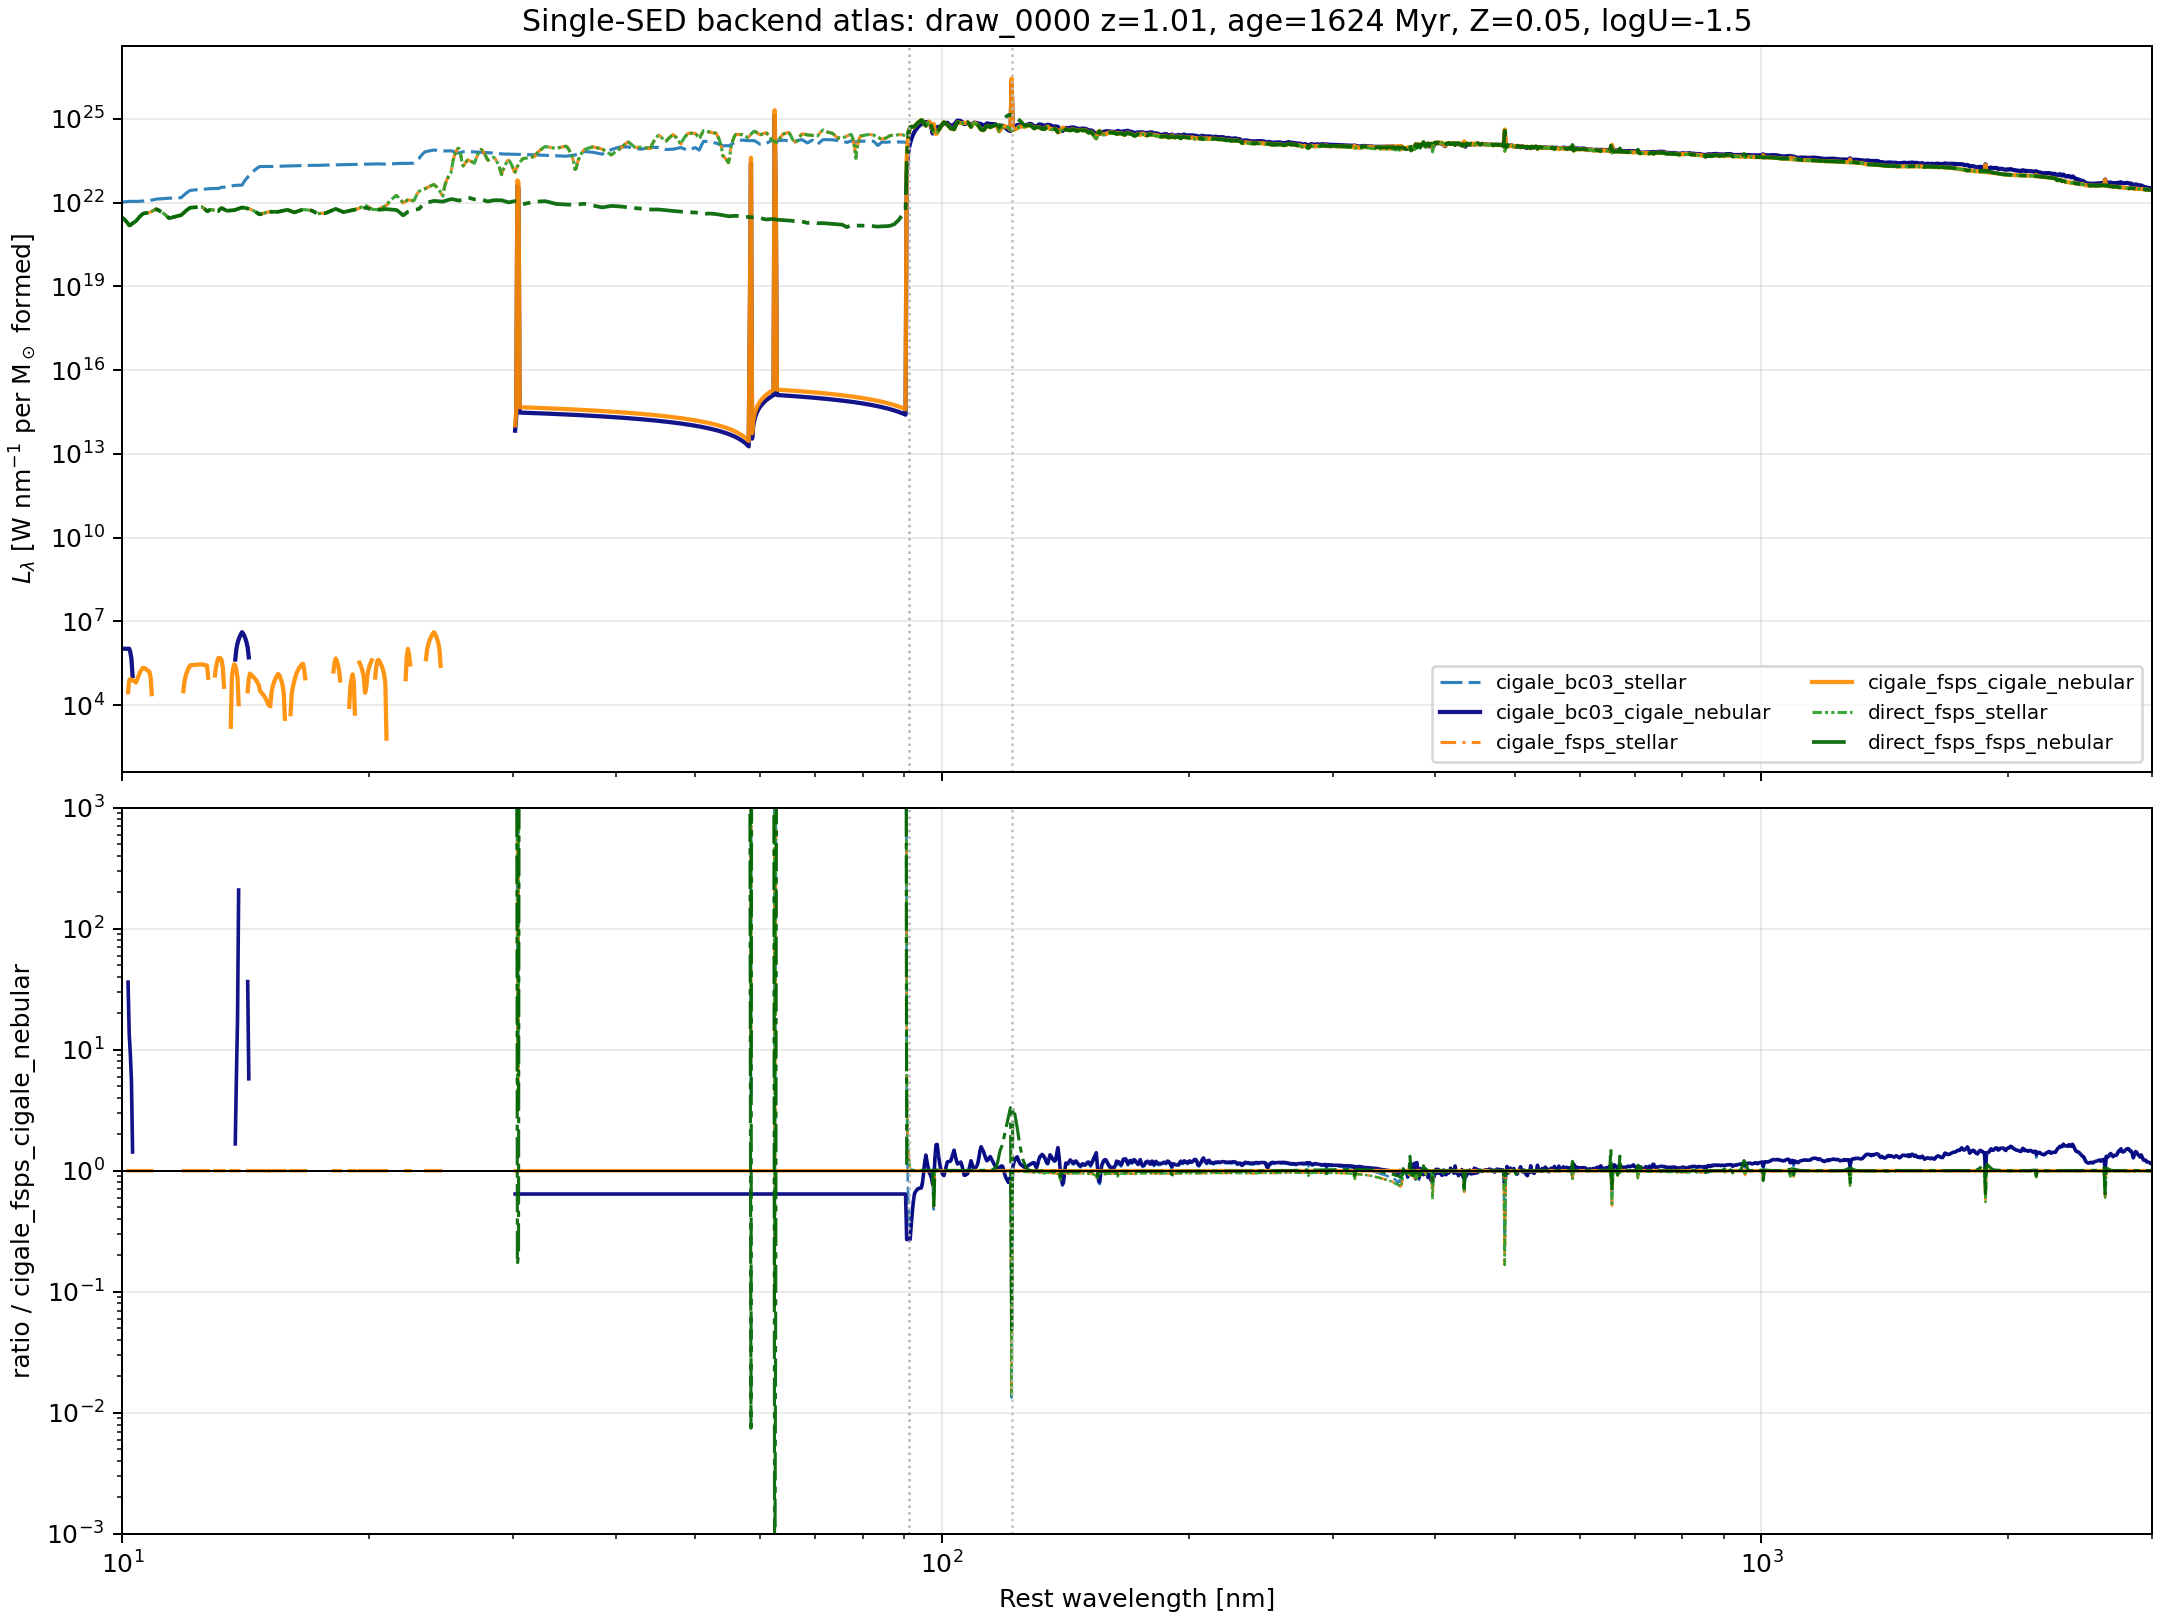

/Users/gregoire/Documents/Sedfitting/CompoSED/outputs/validation_backend_cross_validation/single_sed_photometry_atlas.png


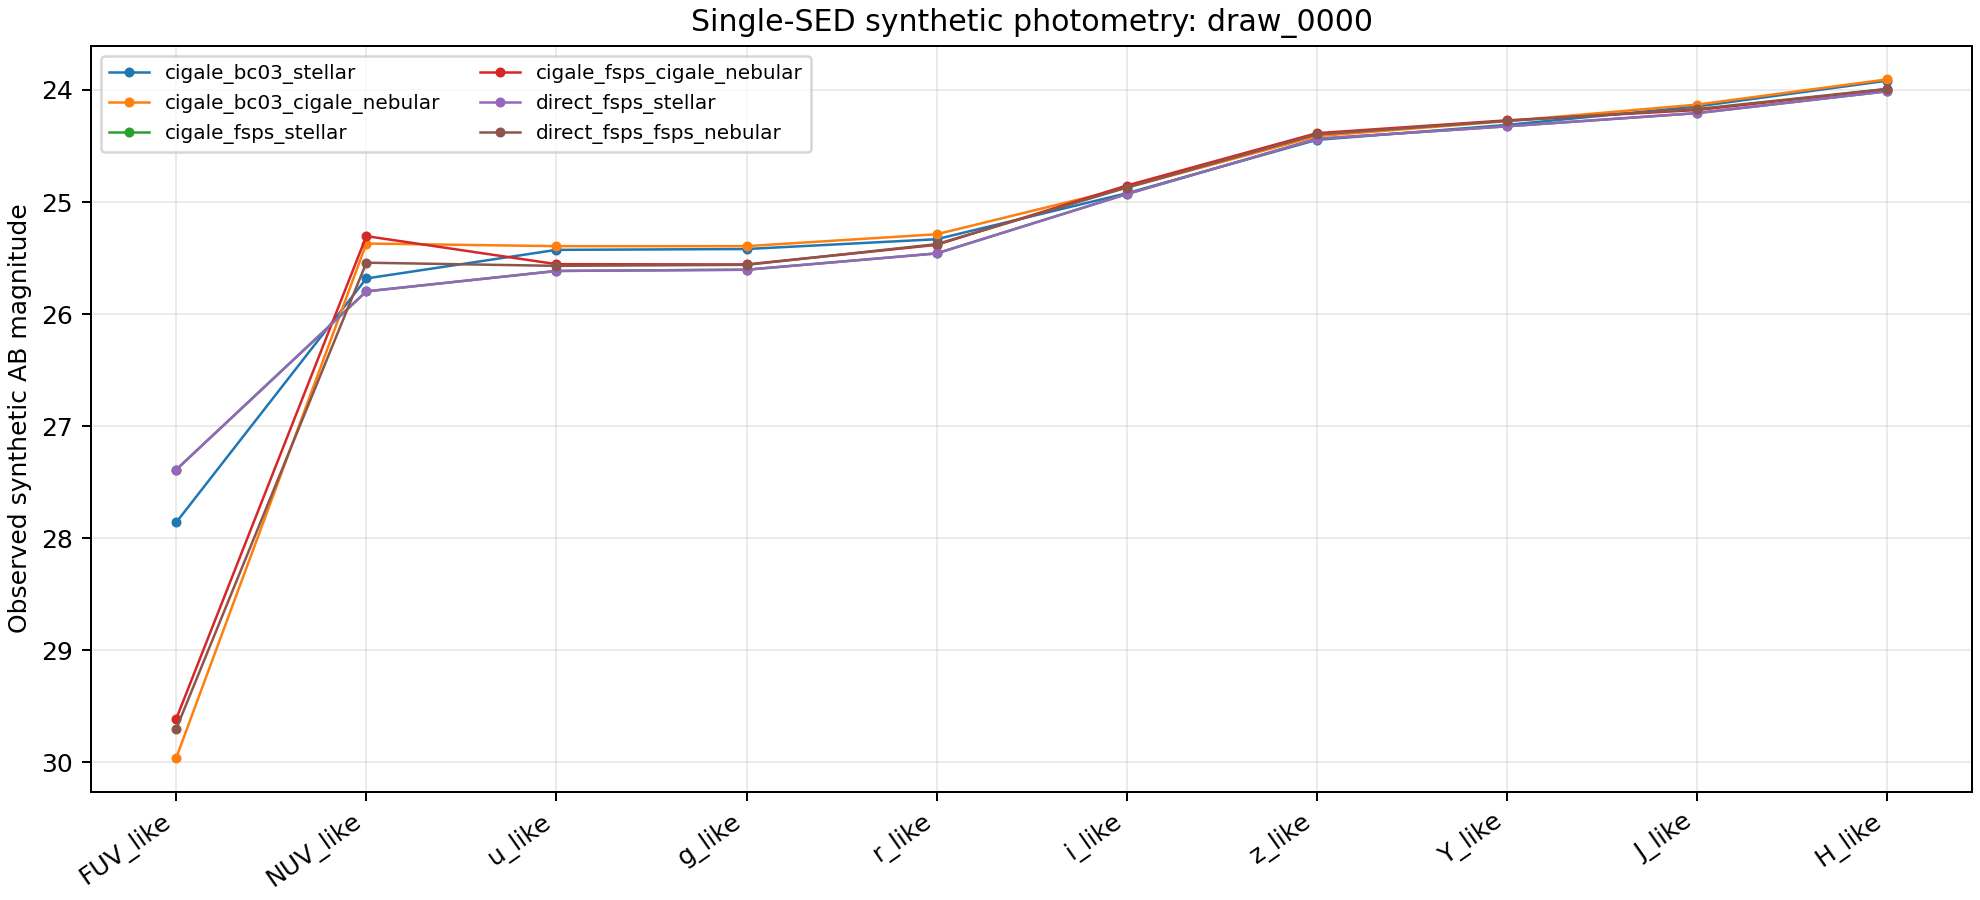

/Users/gregoire/Documents/Sedfitting/CompoSED/outputs/validation_backend_cross_validation/sweep_max_abs_delta_mag_heatmap.png


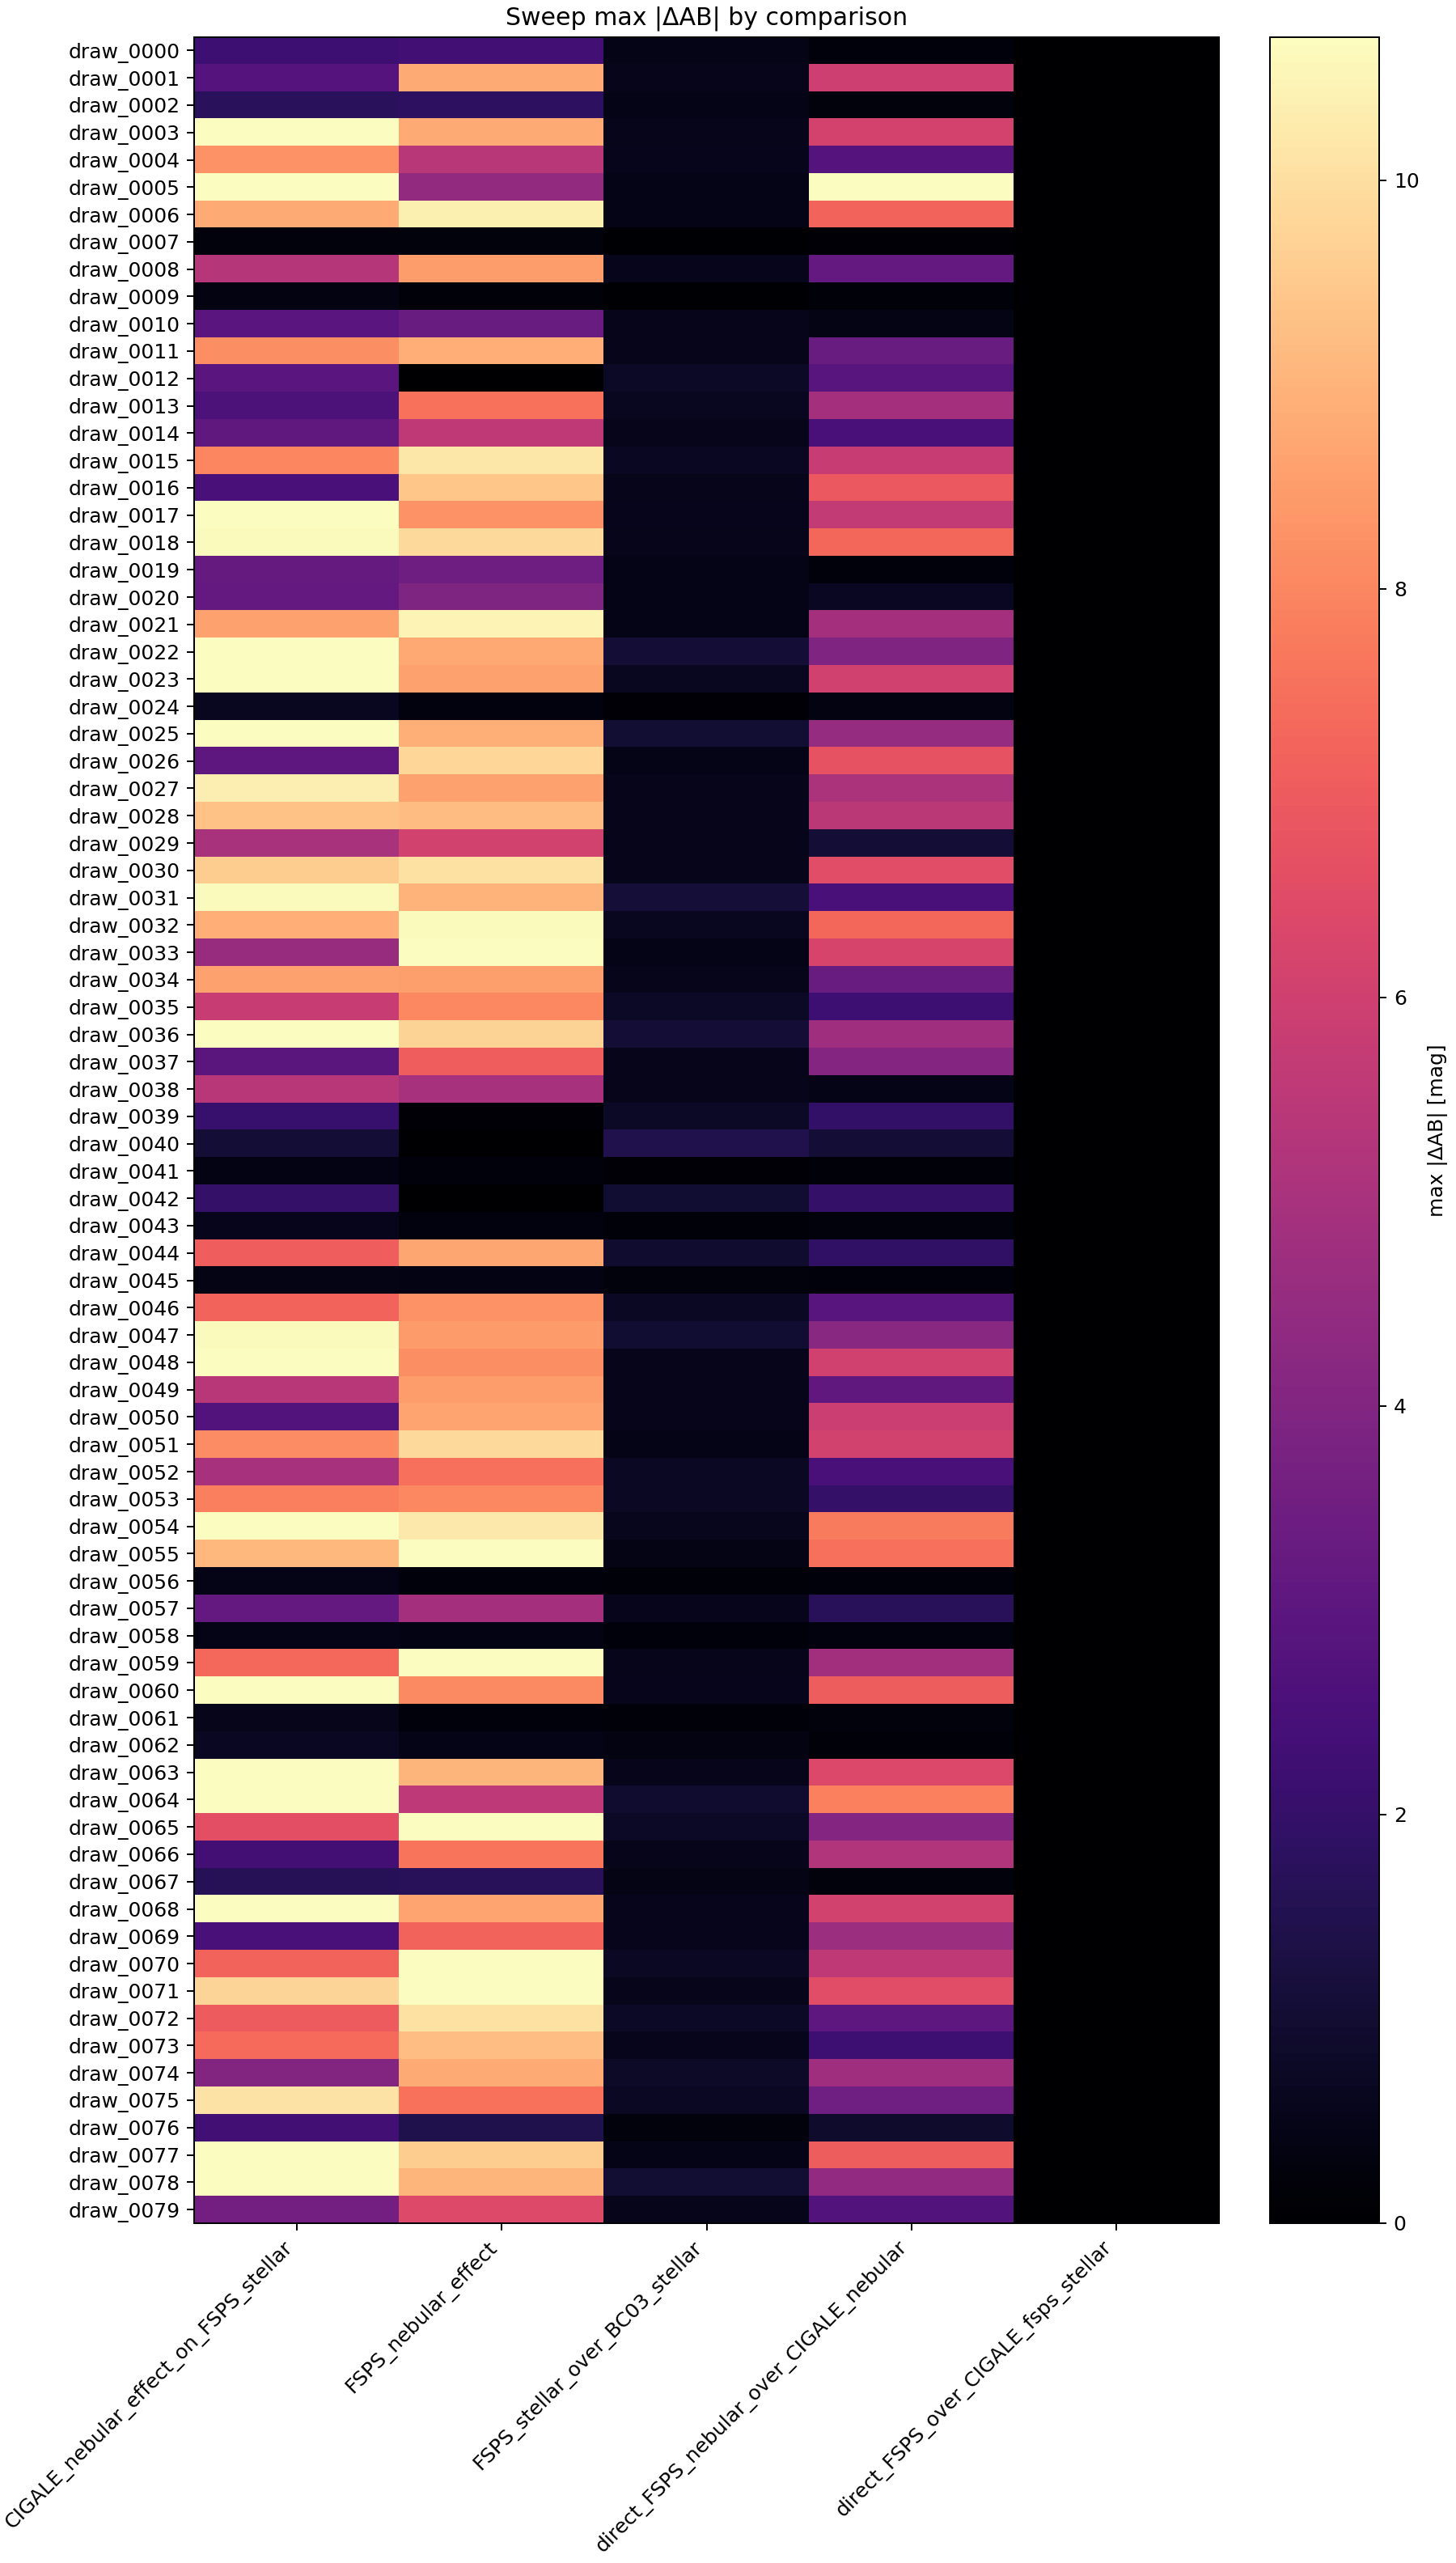

/Users/gregoire/Documents/Sedfitting/CompoSED/outputs/validation_backend_cross_validation/discrepancy_status_counts.png


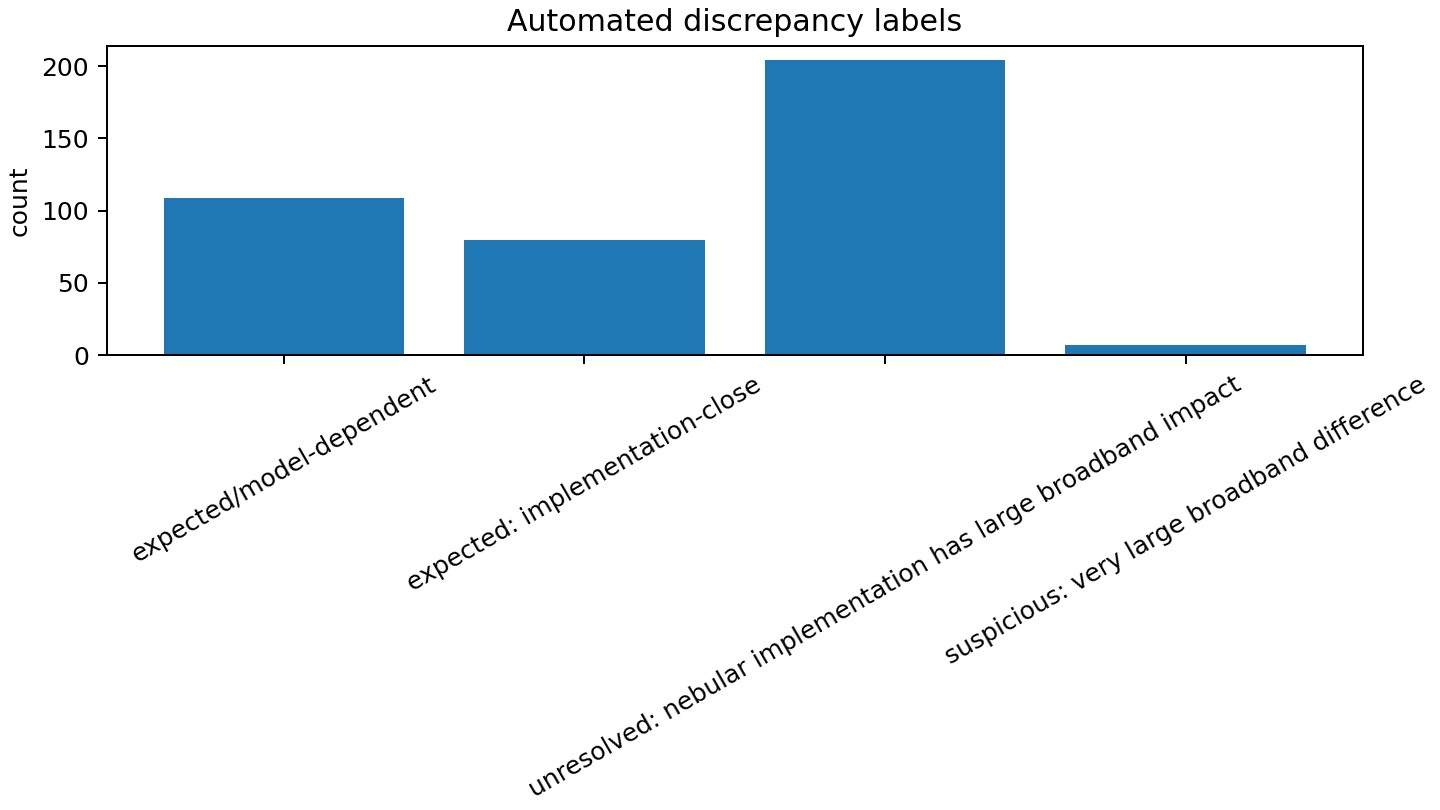

In [4]:
from IPython.display import Image, display

for filename in [
    "single_sed_cross_validation_atlas.png",
    "single_sed_photometry_atlas.png",
    "sweep_max_abs_delta_mag_heatmap.png",
    "discrepancy_status_counts.png",
]:
    path = OUTPUT_DIR / filename
    print(path)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print("missing")


## 5. Spectral Window Metrics

Ratios are summarized in physically motivated windows:

- 10-91 nm: Lyman continuum;
- 91-121.6 nm: near Ly-alpha / Lyman edge;
- 121.6-300 nm: non-ionizing UV;
- 300-900 nm: optical;
- 900-2500 nm: NIR.


/var/folders/y8/jsy3hf3s05scysktw741dp6m0000gn/T/ipykernel_63588/648450959.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, i][np.isfinite(data[:, i])] for i in range(len(windows))], labels=[w.replace("median_log10_ratio_", "") for w in windows])
/var/folders/y8/jsy3hf3s05scysktw741dp6m0000gn/T/ipykernel_63588/648450959.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, i][np.isfinite(data[:, i])] for i in range(len(windows))], labels=[w.replace("median_log10_ratio_", "") for w in windows])
/var/folders/y8/jsy3hf3s05scysktw741dp6m0000gn/T/ipykernel_63588/648450959.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support

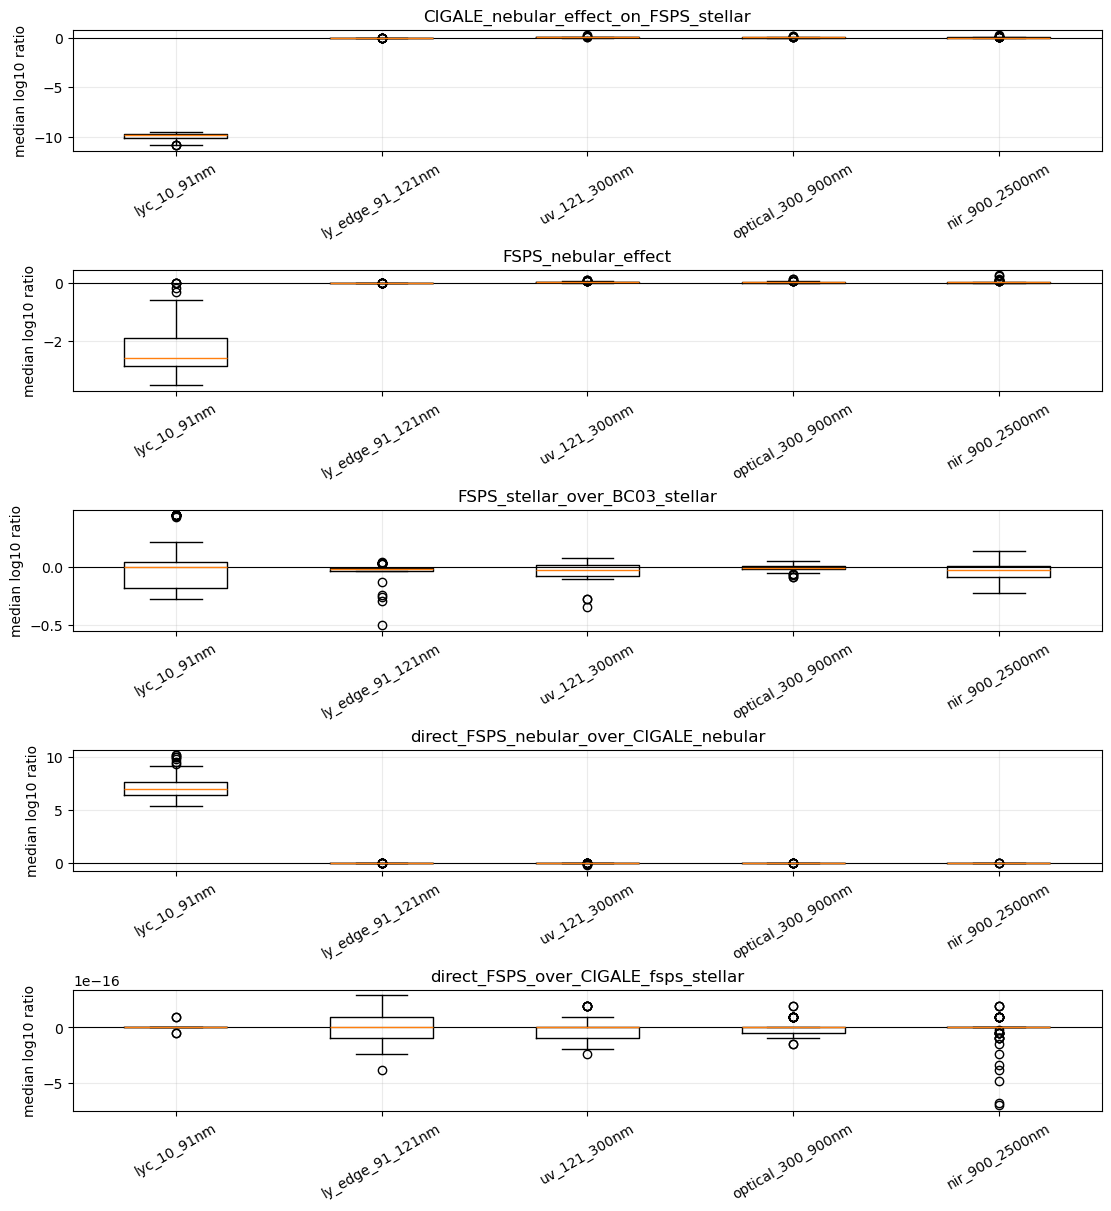

In [5]:
if metrics_path.exists():
    windows = [
        "median_log10_ratio_lyc_10_91nm",
        "median_log10_ratio_ly_edge_91_121nm",
        "median_log10_ratio_uv_121_300nm",
        "median_log10_ratio_optical_300_900nm",
        "median_log10_ratio_nir_900_2500nm",
    ]
    comparisons = sorted(set(row["comparison"] for row in metrics))
    fig, axes = plt.subplots(len(comparisons), 1, figsize=(11, 2.4 * len(comparisons)), constrained_layout=True)
    if len(comparisons) == 1:
        axes = [axes]
    for ax, comparison in zip(axes, comparisons):
        subset = [row for row in metrics if row["comparison"] == comparison]
        data = np.asarray([[finite_float(row.get(window)) for window in windows] for row in subset])
        ax.boxplot([data[:, i][np.isfinite(data[:, i])] for i in range(len(windows))], labels=[w.replace("median_log10_ratio_", "") for w in windows])
        ax.axhline(0.0, color="black", lw=0.8)
        ax.set_ylabel("median log10 ratio")
        ax.set_title(comparison)
        ax.tick_params(axis="x", rotation=30)
        ax.grid(alpha=0.25)
    plt.show()


## 6. Audit Checklist

- **Data entering:** sampled physical parameter vectors saved in `parameter_draws.json`.
- **Transformations:** each backend produces rest-frame spectra per formed solar mass; the script converts spectra to common units and synthetic observed photometry.
- **Units:** rest wavelength is nm in saved spectra; luminosity density is W/nm per solar mass formed; synthetic photometry is maggies.
- **Masks/cuts:** no data masks; ratios ignore non-finite or non-positive denominator pixels.
- **Normalization:** spectra are compared per formed solar mass; photometry applies `10**log10_mass` once during synthetic observation.
- **Final quantities:** spectra, synthetic photometry, windowed log-ratios, broadband magnitude offsets, and audit labels.
- **Most important files:** `reference_spectra.npz`, `cue_spectra.npz`, `cross_validation_metrics.json`, and the generated atlas PNGs.
- **Caveat:** BC03, FSPS, and DSPS/Cue are not expected to be identical. Large UV/ionizing differences can be normal; large red-optical disagreements between direct FSPS and CIGALE `fsps_stellar` are more suspicious.
